# **RAG (Retrieval Augmented Generation) Tutorial**

## **1. Environment Setup**

**1-1. Install packages**

In [ ]:
!pip install langchain langchain-openai langchain-community faiss-cpu pypdf tiktoken beautifulsoup4 -q

**1-2. Set API key**

In [ ]:
import os
os.environ['OPENAI_API_KEY'] = "YOUR API KEY"


## **2. What is RAG?**

**RAG (Retrieval Augmented Generation)** grounds LLM responses in retrieved documents, reducing hallucination and enabling access to private/up-to-date knowledge.


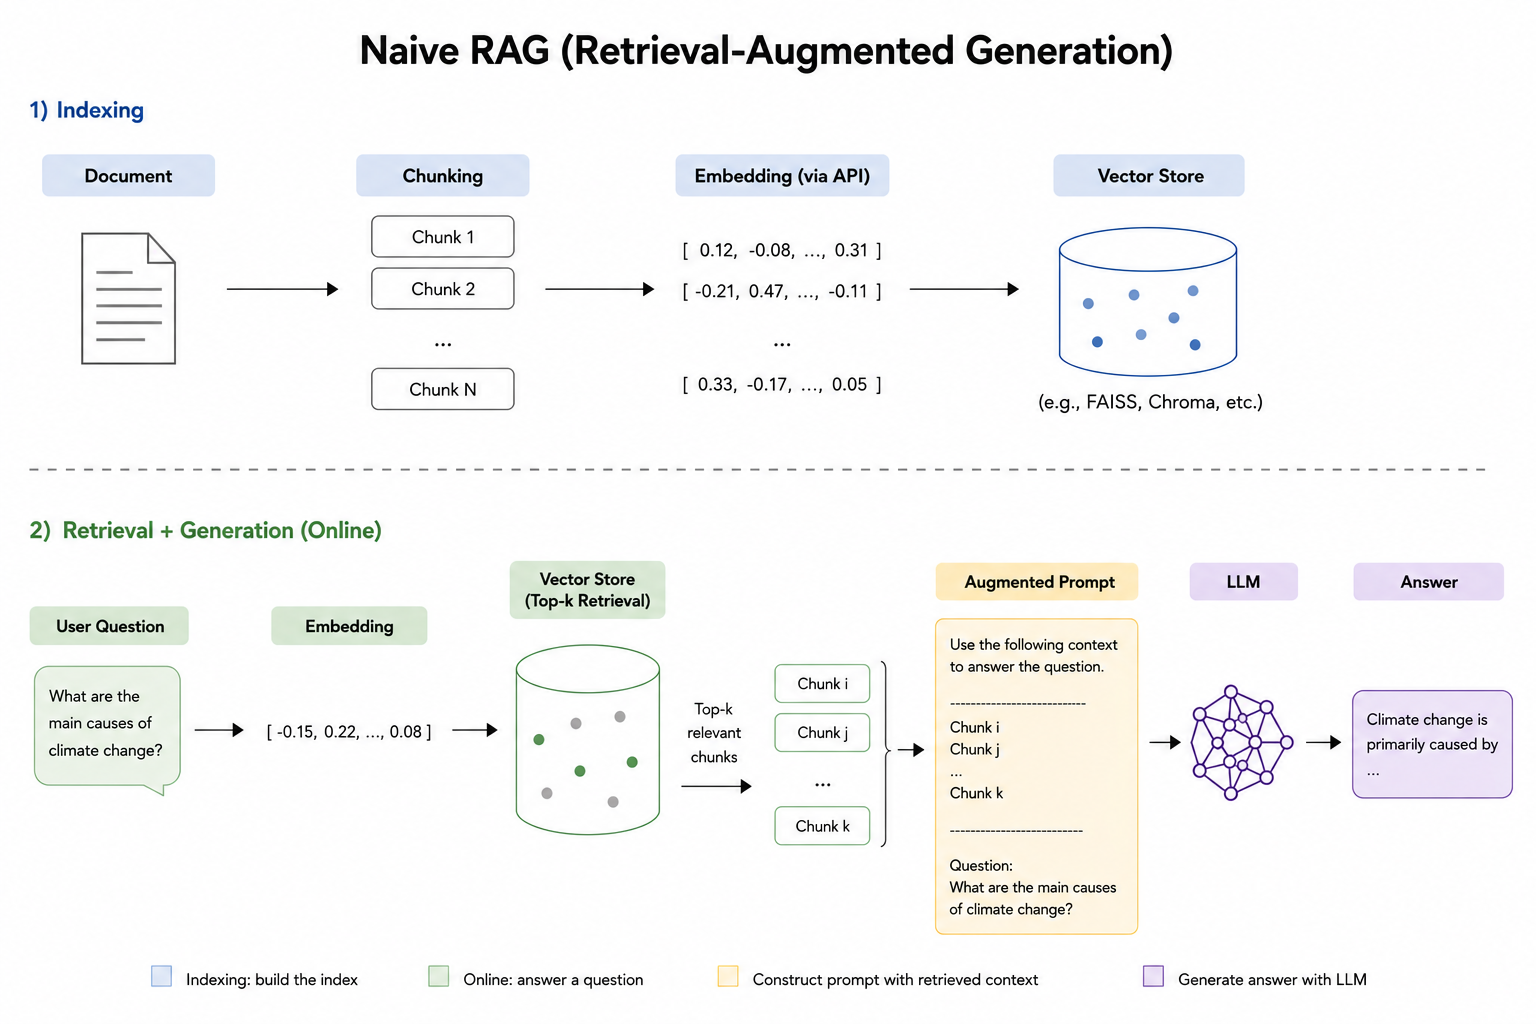

## **3. Document Loading**

**3-1. Creating Document objects (inline text)**

In [ ]:
from langchain_core.documents import Document

# Sample documents based on the real PRISM-AI proposal
documents = [
    Document(
        page_content=(
            "PRISM-AI (Platform for Real-world Innovation in Smart Manufacturing through AI) "
            "is a Korean national research consortium led by Prof. Seunghwa Ryu at KAIST "
            "Department of Mechanical Engineering. Funded under the InnoCORE initiative, it "
            "aims to develop an end-to-end LLM-based manufacturing AI automation system "
            "integrating design, materials, manufacturing, and operations (PHM). "
            "Total budget is 37.5 billion KRW over 5 years (2025-2029), with 50 postdocs "
            "recruited annually, including 16 international fellows."
        ),
        metadata={"source": "prism_ai_overview", "page": 1}
    ),
    Document(
        page_content=(
            "PRISM-AI consists of five research groups. "
            "(1) Design Group: multi-physics simulation + AI inverse design to derive optimal "
            "design parameters from performance requirements via LLM interface. "
            "(2) Materials Group: physics-informed ML for property prediction and LLM-guided "
            "materials recommendation. "
            "(3) Manufacturing Group: LLM-controlled multi-agent platform for process parameter "
            "optimization and equipment control (3D printing, injection molding, machining). "
            "(4) Operations (PHM) Group: predictive maintenance using sensor data with LLM-based "
            "anomaly explanation targeting >=99% detection accuracy. "
            "(5) AI Interface Group: natural language interface allowing non-experts to control "
            "the full manufacturing pipeline with plain-language commands, targeting >=90% accuracy."
        ),
        metadata={"source": "research_groups", "page": 1}
    ),
    Document(
        page_content=(
            "PRISM-AI core technologies include: "
            "Large Language Models (LLMs) for natural language manufacturing control; "
            "Multi-agent systems with MCP (Model Context Protocol) integration across modules; "
            "RAG (Retrieval Augmented Generation) for knowledge-based query answering over "
            "internal design/process documentation; "
            "Physics-Informed Machine Learning (PIML) and Graph Neural Networks (GNN) for "
            "materials property prediction; "
            "Surrogate models and generative AI for inverse design automation; "
            "PHM (Prognostics and Health Management) algorithms for anomaly detection."
        ),
        metadata={"source": "core_technologies", "page": 1}
    ),
    Document(
        page_content=(
            "PRISM-AI industry partners and target sectors: "
            "Shipbuilding — HD Korea Shipbuilding & Offshore Engineering (complex hull design automation); "
            "Automotive — Hyundai Motor (process simulation, quality prediction, thermal research lab); "
            "Electronics — LG Electronics (product design function acquisition); "
            "Heavy machinery — Samsung Heavy Industries (equipment condition monitoring); "
            "Startups — OnePredict (PHM algorithms), Nanialabs (low-code LLM tools), "
            "Omelet (AI automation for SMEs). "
            "Government labs: KIMM, KITECH, KIMS, KERI (14 teams total). "
            "Expected outcomes: yield improvement >=10%, design time reduction >=50%."
        ),
        metadata={"source": "industry_partners", "page": 1}
    ),
    Document(
        page_content=(
            "PRISM-AI 5-year research roadmap: "
            "Year 1 (2025): Surrogate model-based inverse design AI, materials property prediction "
            "models, manufacturing LLM demo, 10 pilot partners secured. "
            "Year 2 (2026): LLM module upgrades, MCP integration, 20+ pilot demonstrations, "
            "50+ SCI papers, LLM prototype release. "
            "Year 3 (2027): Multi-agent system integration test, expansion to semiconductor and "
            "shipbuilding sectors, public API release, 50+ SCI papers. "
            "Year 4 (2028): Fully autonomous manufacturing cell demo, full-cycle system stability. "
            "Year 5 (2029): TRL 7 achieved, 10+ industry demonstrations, technology transfer. "
            "Cumulative targets: 300+ SCI papers, 20+ patents, 250 postdocs trained."
        ),
        metadata={"source": "research_roadmap", "page": 1}
    ),
]

print(f"Loaded {len(documents)} documents")
for doc in documents:
    print(f"  [{doc.metadata['source']}] {doc.page_content[:70]}...")


**3-2. Loading a PDF**

In [ ]:
# Load a PDF file — upload to Colab first, or provide a URL
from langchain_community.document_loaders import PyPDFLoader
import urllib.request

# Example: download the original RAG paper
pdf_url = "https://arxiv.org/pdf/2005.11401"
urllib.request.urlretrieve(pdf_url, "/tmp/rag_paper.pdf")

pdf_loader = PyPDFLoader("/tmp/rag_paper.pdf")
pdf_docs = pdf_loader.load()

print(f"PDF loaded: {len(pdf_docs)} pages")
print(f"Preview (page 1):\n{pdf_docs[0].page_content[:400]}...")


**3-3. Loading a web page**

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
import bs4

loader = WebBaseLoader(
    web_paths=["https://en.wikipedia.org/wiki/Retrieval-augmented_generation"],
    bs_kwargs=dict(parse_only=bs4.SoupStrainer(["h1", "h2", "p"]))
)
web_docs = loader.load()
print(f"Web pages loaded: {len(web_docs)}")
print(f"Preview:\n{web_docs[0].page_content[:400]}...")


## **4. Text Splitting**

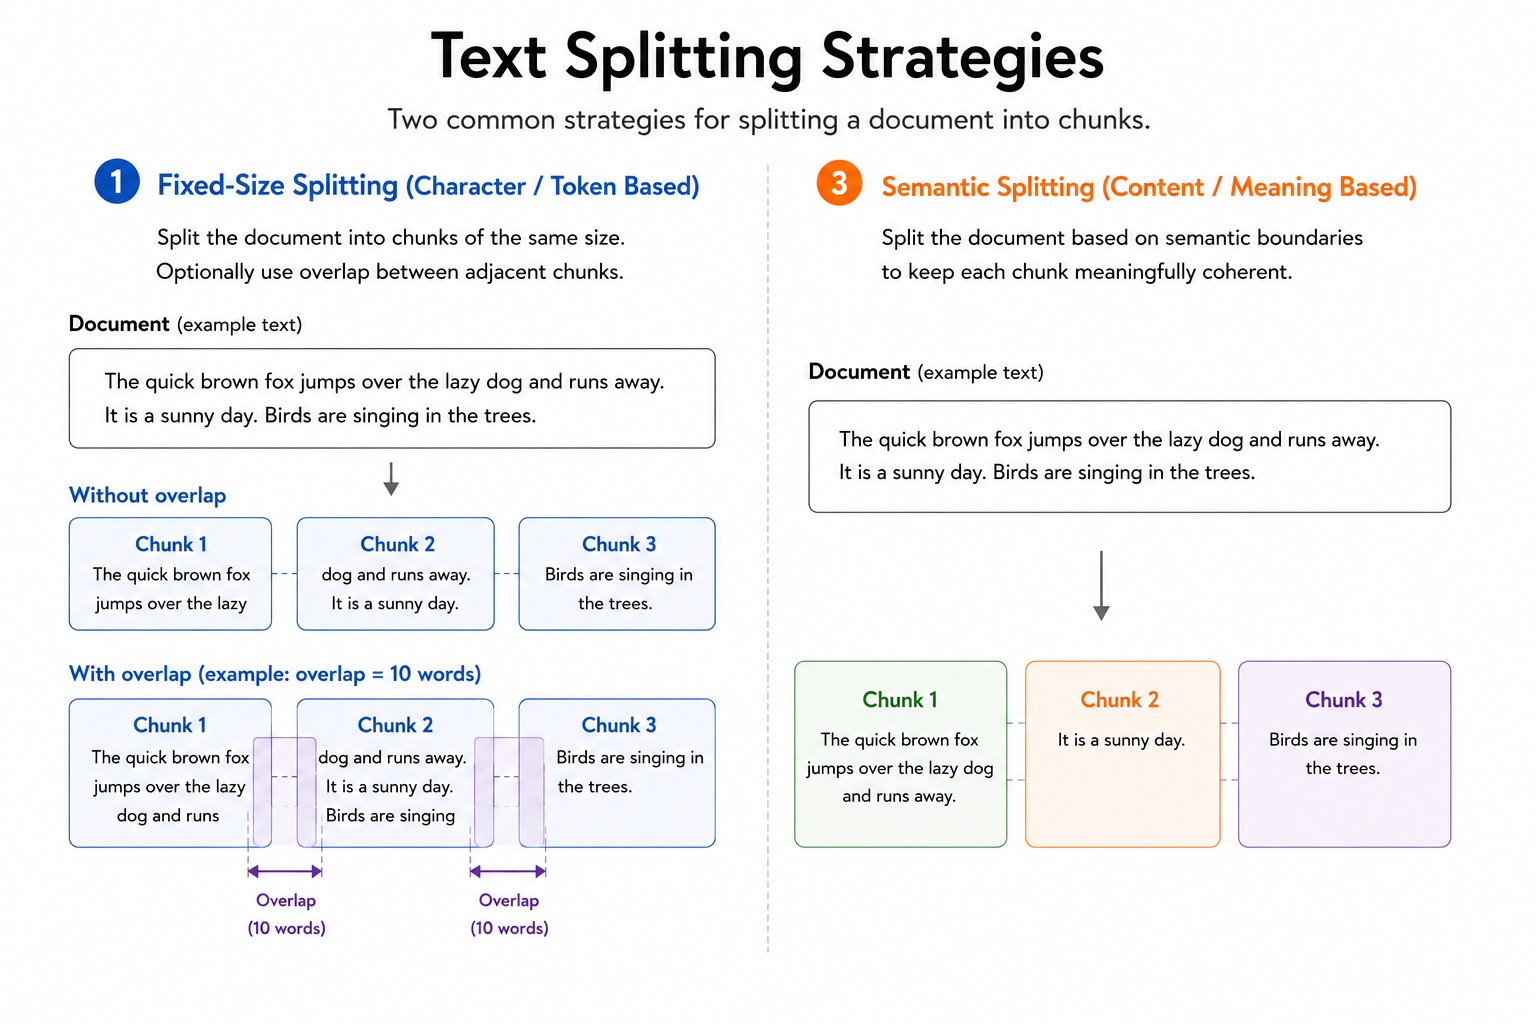

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# RecursiveCharacterTextSplitter tries to split on paragraphs → lines → sentences → words
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,       # max characters per chunk
    chunk_overlap=40,     # overlap to preserve context across chunks
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = splitter.split_documents(documents)

print(f"Before splitting : {len(documents)} documents")
print(f"After splitting  : {len(chunks)} chunks")
print()
print("=== Chunk examples ===")
for i, chunk in enumerate(chunks[:3]):
    print(f"Chunk {i+1} ({len(chunk.page_content)} chars) [{chunk.metadata['source']}]:")
    print(f"  {chunk.page_content}")
    print()


> 💡 **Chunk size guide:** too small = lost context; too large = noisy retrieval. Typical: 200–1000 chars, overlap ≈ 10–20%.


## **5. Embeddings & Vector Store**

**5-1. Creating embeddings**

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

sample = "What are the five research groups in PRISM-AI?"
vector = embeddings.embed_query(sample)

print(f"Text   : {sample}")
print(f"Vector dim : {len(vector)}")
print(f"First 5 values: {vector[:5]}")


**5-2. Building a FAISS vector store**

In [ ]:
from langchain_community.vectorstores import FAISS

# Embed all chunks and index them in FAISS
vectorstore = FAISS.from_documents(chunks, embeddings)

print(f"Vector store built! Indexed vectors: {vectorstore.index.ntotal}")

# Optionally save to disk
vectorstore.save_local("/tmp/prism_ai_index")
print("Saved to /tmp/prism_ai_index")


## **6. Retrieval**

**6-1. Similarity search**

In [ ]:
query = "What industries does PRISM-AI collaborate with?"
results = vectorstore.similarity_search(query, k=2)

print(f"Query: {query}\n")
for i, doc in enumerate(results, 1):
    print(f"[Result {i}] source: {doc.metadata['source']}")
    print(f"Content: {doc.page_content}")
    print()


**6-2. Similarity search with scores**

In [ ]:
query = "PRISM-AI research roadmap and milestones"
results_with_scores = vectorstore.similarity_search_with_score(query, k=3)

print(f"Query: {query}\n")
for doc, score in results_with_scores:
    print(f"Score: {score:.4f} (lower = more similar)")
    print(f"Source: {doc.metadata['source']}")
    print(f"Content: {doc.page_content[:120]}...")
    print()


**6-3. Creating a Retriever**

In [ ]:
# Wrap the vector store as a LangChain Retriever
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

docs = retriever.invoke("LLM-based manufacturing automation")
print(f"Retrieved {len(docs)} documents")
for doc in docs:
    print(f"  - [{doc.metadata['source']}] {doc.page_content[:80]}...")


## **7. Building a RAG Chain**

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

prompt = ChatPromptTemplate.from_template("""
You are a helpful assistant. Use only the context below to answer the question.
If the answer is not in the context, say "Not found in the provided documents."

Context:
{context}

Question: {question}

Answer:
""")

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

questions = [
    "What is PRISM-AI and who leads it?",
    "What are the key technologies used by PRISM-AI?",
    "What are the expected outcomes by Year 5 (2029)?",
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {rag_chain.invoke(q)}")
    print("-" * 60)


## **8. Conversational RAG**

Rewrites ambiguous follow-up questions using chat history before retrieval.


In [ ]:
from langchain.chains import create_history_aware_retriever, create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Step 1: Rewrite ambiguous follow-up questions using chat history
contextualize_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Given the chat history and the latest user question, "
     "rewrite it as a standalone question (no pronouns/references). "
     "Do NOT answer — only reformulate if needed."),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])
history_aware_retriever = create_history_aware_retriever(
    llm, retriever, contextualize_prompt
)

# Step 2: QA prompt that includes history
qa_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a helpful assistant. Use only the context below to answer.\n\n"
     "Context:\n{context}"),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])
qa_chain = create_stuff_documents_chain(llm, qa_prompt)

# Combine into full conversational RAG chain
conv_rag_chain = create_retrieval_chain(history_aware_retriever, qa_chain)


In [ ]:
chat_history = []

conversations = [
    "Tell me about PRISM-AI.",
    "What are its five research groups?",        # "its" refers to PRISM-AI
    "Which group is responsible for PHM?",       # ambiguous without history
    "What accuracy target does that group aim for?",  # "that group" = Operations group
]

for question in conversations:
    result = conv_rag_chain.invoke({
        "input": question,
        "chat_history": chat_history
    })
    answer = result["answer"]
    chat_history += [HumanMessage(content=question), AIMessage(content=answer)]

    print(f"Q: {question}")
    print(f"A: {answer}")
    print("-" * 60)

print(f"\nTotal turns: {len(chat_history)//2}")


## **Summary**

Offline: load → split → embed → index. Online: retrieve → generate.
